# Spike Hunter algorithm

Automated Candlestick Spike Pattern Labeling for Cryptocurrency Assets

In [148]:
%pip install pandas numpy matplotlib

162036.56s - pydevd: Sending message related to process being replaced timed-out after 5 seconds



[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# Training and evaluation on a single symbol

[Init] Fetching initial data for SNXBTC ...
[BigSpikeMode] Fallback retained largest spike @ 229
[BigSpikeMode] q=0.96 price_q=0.0348 vol_q=4.43 dyn_price=0.0348 dyn_vol=4.43 labels 63->1
[Init] Dataset prepared. Rows=487 labels=1 raw=63
Label distribution: {0: np.int64(486), 1: np.int64(1)}
[Train] Non-stratified split (too few minority samples).
{np.int64(0): np.float64(0.5010288065843621), np.int64(1): np.float64(243.5)}
[BigSpikeMode] Fallback retained largest spike @ 229
[BigSpikeMode] q=0.96 price_q=0.0348 vol_q=4.43 dyn_price=0.0348 dyn_vol=4.43 labels 63->1
[Init] Dataset prepared. Rows=487 labels=1 raw=63
Label distribution: {0: np.int64(486), 1: np.int64(1)}
[Train] Non-stratified split (too few minority samples).
{np.int64(0): np.float64(0.5010288065843621), np.int64(1): np.float64(243.5)}

=== MODEL EVALUATION (Current Spike Detection) ===
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       122

    accuracy              

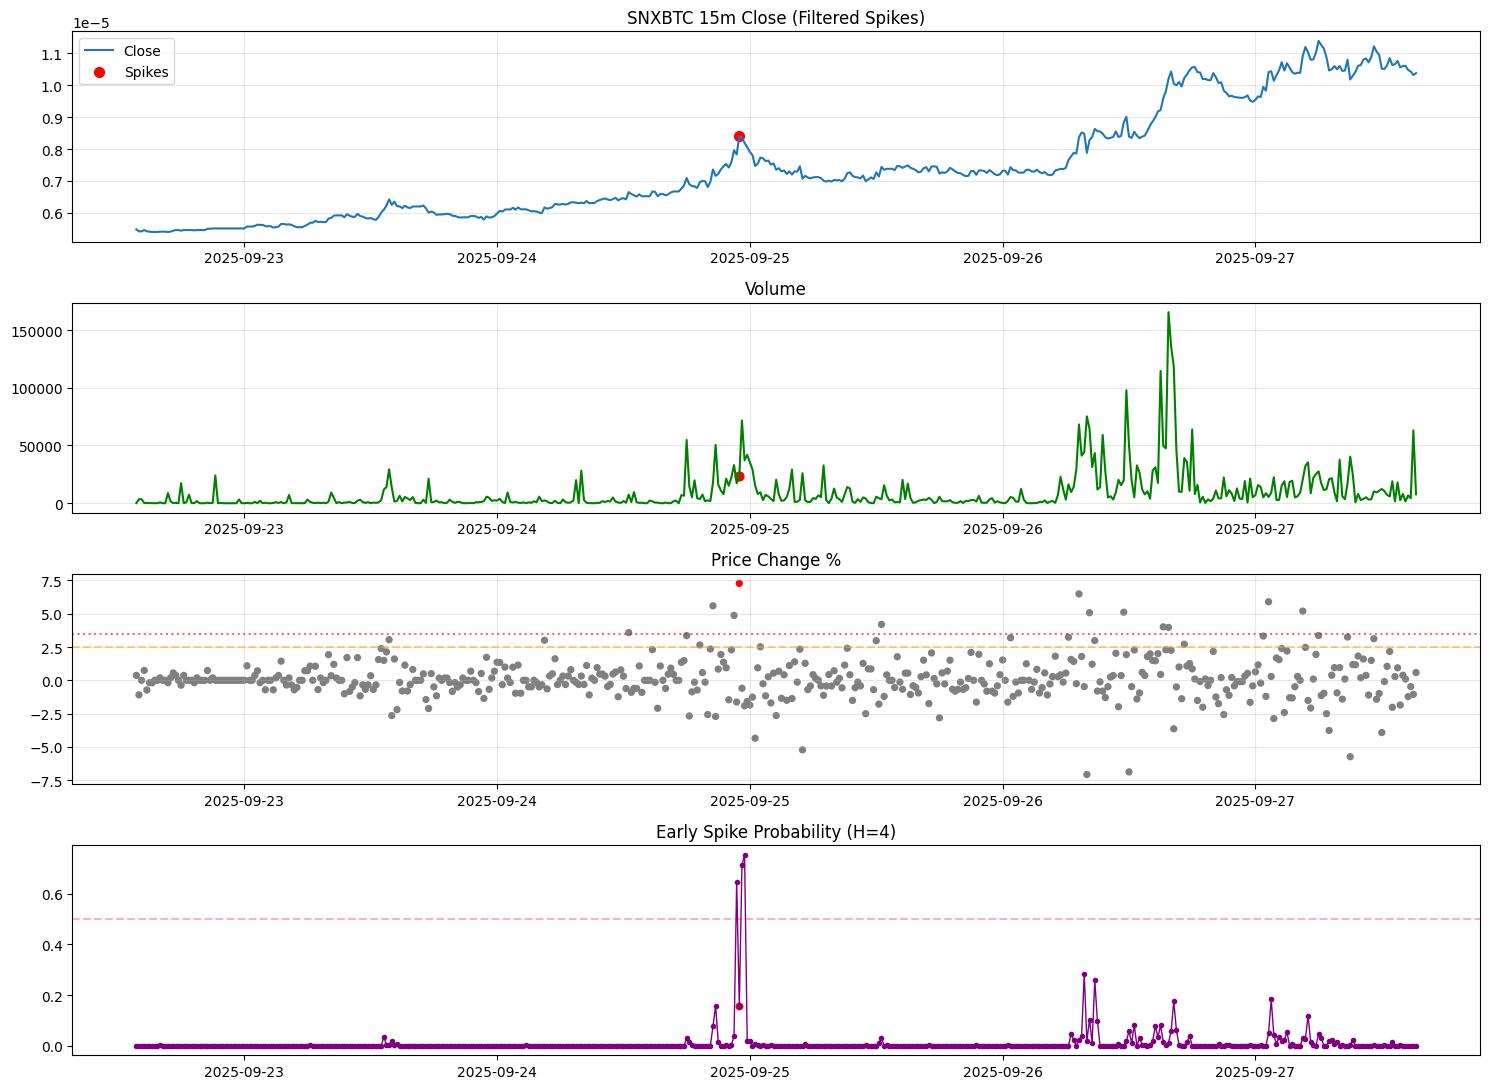

Latest early_spike_proba: 0.0


In [155]:
import pandas as pd
import numpy as np
import requests
from dataclasses import dataclass, field
from typing import List, Optional, Tuple, Dict
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
import joblib
import os

# ================= Unified Fixed Windows & Threshold Constants ================= #
ROLLING_WINDOW = 12
MOMENTUM_LOOKBACK = 3
MOMENTUM_THRESHOLD = 0.015
RSI_OVERSOLD = 30

FIXED_PRICE_THRESHOLD = 0.025
FIXED_VOLUME_THRESHOLD = 2.5
TRADES_RATIO_THRESHOLD = 2.5
QUOTE_VOLUME_RATIO_THRESHOLD = 2.5
MIN_PRICE_MOVE_FOR_ACTIVITY = 0.004
VOLUME_CONFIRM_THRESHOLD = 1.2
EARLY_HORIZON = 4

CHECKPOINT_DIR = "../checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


@dataclass
class TrainingArtifacts:
    df: pd.DataFrame
    clf: Optional[RandomForestClassifier] = None
    early_clf: Optional[RandomForestClassifier] = None
    magnitude_reg: Optional[RandomForestRegressor] = None
    feature_list_current: List[str] = field(default_factory=list)
    early_feature_list: List[str] = field(default_factory=list)
    big_price_threshold_used: Optional[float] = None
    big_volume_threshold_used: Optional[float] = None


class SpikeHunterV2:
    """Training & Research class for Spike Hunter V2 (purity deprecated). Now stateful with self.df loaded at instantiation."""

    BASE_FEATURES = [
        "price_change",
        "price_change_abs",
        "body_size_pct",
        "upper_wick_ratio",
        "lower_wick_ratio",
        "is_bullish",
        "close_open_ratio",
        "price_zscore",
        "volume_ratio",
        "volume_zscore",
        "momentum_3",
        "momentum_5",
        "range_pct",
        "close_to_high",
        "close_to_low",
        "taker_base",
        "taker_quote",
        "taker_buy_ratio",
        "quote_asset_volume",
        "number_of_trades",
        "trades_ratio",
        "trades_zscore",
        "quote_volume_ratio",
    ]

    EARLY_FEATURES = [
        "std_ratio_8_20",
        "vol_ratio_slope_3",
        "vol_ratio_accel",
        "trades_ratio_slope_3",
        "quote_vol_ratio_slope_3",
        "pc_1",
        "pc_2c",
        "pc_3c",
        "pc_pos_count_5",
        "pc_abs_sum_5",
        "taker_buy_ratio",
        "taker_buy_ratio_slope_5",
        "body_size_pct_z",
        "vol_compression_flag",
        "volume_ratio",
        "price_zscore",
    ]

    def __init__(
        self,
        symbol: str = "SNXBTC",
        early_horizon: int = EARLY_HORIZON,
        big_spike_only: bool = True,
        dynamic_quantile: float = 0.96,
        big_price_multiplier: float = 1.35,
        big_volume_multiplier: float = 1.25,
        min_samples_for_dynamic: int = 120,
        fallback_big_spike_fail: bool = True,
    ):
        self.symbol = symbol
        self.early_horizon = early_horizon
        self.big_spike_only = big_spike_only
        self.dynamic_quantile = dynamic_quantile
        self.big_price_multiplier = big_price_multiplier
        self.big_volume_multiplier = big_volume_multiplier
        self.min_samples_for_dynamic = min_samples_for_dynamic
        self.fallback_big_spike_fail = fallback_big_spike_fail
        self.artifacts: Optional[TrainingArtifacts] = None
        self._big_price_threshold_used = None
        self._big_volume_threshold_used = None
        # Load raw data immediately and build feature dataset
        print(f"[Init] Fetching initial data for {self.symbol} ...")
        self.df = self.fetch_binance_klines(self.symbol, interval="15m", limit=500)
        self.add_enhanced_features_instance()  # builds labels & features in-place
        print(
            f"[Init] Dataset prepared. Rows={len(self.df)} labels={int(self.df['label'].sum())} raw={int(self.df['raw_label'].sum())}"
        )

    # ---------------- Data Fetch & Feature Engineering (stateful) ---------------- #
    def fetch_binance_klines(
        self,
        symbol: str,
        interval: str = "15m",
        limit: int = 500,
        end_time: Optional[int] = None,
    ) -> pd.DataFrame:
        url = "https://api.binance.com/api/v3/klines"
        params = {"symbol": symbol, "interval": interval, "limit": limit}
        if end_time:
            params["endTime"] = end_time
        resp = requests.get(url, params=params, timeout=10)
        resp.raise_for_status()
        data = resp.json()
        df = pd.DataFrame(
            data,
            columns=[
                "open_time",
                "open",
                "high",
                "low",
                "close",
                "volume",
                "close_time",
                "quote_asset_volume",
                "number_of_trades",
                "taker_base",
                "taker_quote",
                "ignore",
            ],
        )
        num_cols = [
            "open",
            "high",
            "low",
            "close",
            "volume",
            "quote_asset_volume",
            "number_of_trades",
            "taker_base",
            "taker_quote",
        ]
        df[num_cols] = df[num_cols].astype(float)
        df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms")
        return (
            df[
                [
                    "timestamp",
                    "open",
                    "high",
                    "low",
                    "close",
                    "volume",
                    "quote_asset_volume",
                    "taker_base",
                    "taker_quote",
                    "number_of_trades",
                ]
            ]
            .sort_values("timestamp")
            .reset_index(drop=True)
        )

    def calculate_rsi(self, df: pd.DataFrame, window: int = 14) -> pd.DataFrame:
        delta = df["close"].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window).mean()
        rs = gain / (loss + 1e-6)
        df["rsi"] = 100 - (100 / (1 + rs))
        return df

    def base_features(self, window: int = ROLLING_WINDOW):
        df = self.df.copy().sort_values("timestamp").reset_index(drop=True)
        eff = window
        df["price_change"] = df["close"].pct_change()
        df["price_change_abs"] = df["price_change"].abs()
        df["body_size"] = (df["close"] - df["open"]).abs()
        df["body_size_pct"] = df["body_size"] / (df["open"] + 1e-6)
        df["upper_wick"] = df["high"] - df[["close", "open"]].max(axis=1)
        df["lower_wick"] = df[["close", "open"]].min(axis=1) - df["low"]
        df["upper_wick_ratio"] = df["upper_wick"] / (df["body_size"] + 1e-6)
        df["lower_wick_ratio"] = df["lower_wick"] / (df["body_size"] + 1e-6)
        df["total_range"] = df["high"] - df["low"]
        df["range_pct"] = df["total_range"] / (df["open"] + 1e-6)
        df["is_bullish"] = (df["close"] > df["open"]).astype(int)
        df["close_open_ratio"] = (df["close"] - df["open"]) / (df["open"] + 1e-6)
        df["price_ma"] = df["close"].rolling(eff).mean()
        df["price_std"] = df["close"].rolling(eff).std()
        df["price_zscore"] = (df["close"] - df["price_ma"]) / (df["price_std"] + 1e-6)
        df["volume_ma"] = df["volume"].rolling(eff).mean()
        df["volume_ratio"] = df["volume"] / (df["volume_ma"] + 1e-6)
        df["volume_zscore"] = (df["volume"] - df["volume_ma"]) / (
            df["volume"].rolling(eff).std() + 1e-6
        )
        if "quote_asset_volume" in df.columns:
            df["quote_volume_ma"] = df["quote_asset_volume"].rolling(eff).mean()
            df["quote_volume_ratio"] = df["quote_asset_volume"] / (
                df["quote_volume_ma"] + 1e-6
            )
        else:
            df["quote_volume_ma"] = 0.0
            df["quote_volume_ratio"] = 0.0
        if "number_of_trades" in df.columns:
            df["trades_ma"] = df["number_of_trades"].rolling(eff).mean()
            df["trades_ratio"] = df["number_of_trades"] / (df["trades_ma"] + 1e-6)
            df["trades_zscore"] = (df["number_of_trades"] - df["trades_ma"]) / (
                df["number_of_trades"].rolling(eff).std() + 1e-6
            )
        else:
            df["trades_ma"] = 0.0
            df["trades_ratio"] = 0.0
            df["trades_zscore"] = 0.0
        df["momentum_3"] = df["close"].pct_change(3)
        df["momentum_5"] = df["close"].pct_change(5)
        df["high_low_ratio"] = df["high"] / (df["low"] + 1e-6)
        df["close_to_high"] = (df["high"] - df["close"]) / (df["high"] + 1e-6)
        df["close_to_low"] = (df["close"] - df["low"]) / (df["close"] + 1e-6)
        if "taker_base" in df.columns:
            df["taker_buy_ratio"] = df["taker_base"] / (df["volume"] + 1e-6)
        else:
            df["taker_buy_ratio"] = 0.0
        df = self.calculate_rsi(df, window=14)
        self.df = df

    def label_spike_patterns(self):
        df = self.df.copy()
        mech_cols = [
            "label_price_volume",
            "label_momentum_cluster",
            "label_rsi_reversal",
            "label_trades_activity",
            "label_quote_liquidity",
        ]
        for mc in mech_cols:
            df[mc] = 0
        for i in range(1, len(df)):
            price_change = df.loc[i, "price_change"]
            vol_ratio = df.loc[i, "volume_ratio"]
            if (
                price_change > FIXED_PRICE_THRESHOLD
                and vol_ratio > FIXED_VOLUME_THRESHOLD
            ):
                df.at[i, "label_price_volume"] = 1
            look_start = max(0, i - MOMENTUM_LOOKBACK)
            recent = df.loc[look_start:i, "price_change"]
            if (
                len(recent) >= MOMENTUM_LOOKBACK
                and (recent > MOMENTUM_THRESHOLD).sum() >= 2
                and recent.sum() > FIXED_PRICE_THRESHOLD
            ):
                df.at[i, "label_momentum_cluster"] = 1
            if i >= 14:
                prev_rsi = df.loc[i - 1, "rsi"]
                curr_rsi = df.loc[i, "rsi"]
                if (
                    prev_rsi < RSI_OVERSOLD
                    and curr_rsi > prev_rsi + 5
                    and price_change > 0.005
                ):
                    df.at[i, "label_rsi_reversal"] = 1
            if (
                df.loc[i, "trades_ratio"] > TRADES_RATIO_THRESHOLD
                and abs(price_change) > MIN_PRICE_MOVE_FOR_ACTIVITY
                and vol_ratio > VOLUME_CONFIRM_THRESHOLD * 0.8
            ):
                df.at[i, "label_trades_activity"] = 1
            if (
                df.loc[i, "quote_volume_ratio"] > QUOTE_VOLUME_RATIO_THRESHOLD
                and abs(price_change) > MIN_PRICE_MOVE_FOR_ACTIVITY
                and vol_ratio > VOLUME_CONFIRM_THRESHOLD * 0.8
            ):
                df.at[i, "label_quote_liquidity"] = 1
        df["_prelim"] = df[mech_cols].sum(axis=1) > 0
        df["label"] = (
            df["_prelim"]
            & (df["volume_ratio"] >= VOLUME_CONFIRM_THRESHOLD)
            & (df["price_change_abs"] >= MIN_PRICE_MOVE_FOR_ACTIVITY)
        ).astype(int)
        df["raw_label"] = df["label"]
        self.df = df

    def add_enhanced_features_instance(self):
        self.base_features(window=ROLLING_WINDOW)
        self.df = self.df.dropna().reset_index(drop=True)
        self.label_spike_patterns()
        df = self.df
        if (
            self.big_spike_only
            and len(df) >= self.min_samples_for_dynamic
            and df["raw_label"].sum() > 0
        ):
            price_q = df["price_change_abs"].quantile(self.dynamic_quantile)
            vol_q = df["volume_ratio"].quantile(self.dynamic_quantile)
            dyn_price = max(FIXED_PRICE_THRESHOLD * self.big_price_multiplier, price_q)
            dyn_vol = max(VOLUME_CONFIRM_THRESHOLD * self.big_volume_multiplier, vol_q)
            self._big_price_threshold_used = float(dyn_price)
            self._big_volume_threshold_used = float(dyn_vol)
            pre = int(df["label"].sum())
            df["label"] = (
                (df["label"] == 1)
                & (df["price_change_abs"] >= dyn_price)
                & (df["volume_ratio"] >= dyn_vol)
            ).astype(int)
            post = int(df["label"].sum())
            if post == 0 and self.fallback_big_spike_fail:
                cand = df.index[df["raw_label"] == 1]
                if len(cand) > 0:
                    idx_top = df.loc[cand, "price_change_abs"].idxmax()
                    df["label"] = 0
                    df.at[idx_top, "label"] = 1
                    post = 1
                    print(f"[BigSpikeMode] Fallback retained largest spike @ {idx_top}")
            print(
                f"[BigSpikeMode] q={self.dynamic_quantile:.2f} price_q={price_q:.4f} vol_q={vol_q:.2f} dyn_price={dyn_price:.4f} dyn_vol={dyn_vol:.2f} labels {pre}->{post}"
            )
        elif self.big_spike_only:
            if df["raw_label"].sum() == 0:
                print("[BigSpikeMode] No raw positives; skipping dynamic filter.")
            else:
                print(
                    f"[BigSpikeMode] Insufficient samples ({len(df)}) for dynamic filter."
                )
        self.df = df

    def build_early_features(self, early_horizon: int = None, label_col: str = "label"):
        if early_horizon is None:
            early_horizon = self.early_horizon
        df = self.df
        future_any = df[label_col].shift(-1).rolling(early_horizon).max()
        df["lead_spike_label"] = future_any.fillna(0).astype(int)
        df["future_spike_magnitude"] = (
            df["price_change_abs"].shift(-1).rolling(early_horizon).max()
        )
        df["rolling_price_std_8"] = df["close"].rolling(8).std()
        df["rolling_price_std_20"] = df["close"].rolling(20).std()
        df["std_ratio_8_20"] = df["rolling_price_std_8"] / (
            df["rolling_price_std_20"] + 1e-6
        )
        df["vol_ratio_slope_3"] = df["volume_ratio"].diff(3)
        df["vol_ratio_accel"] = df["vol_ratio_slope_3"].diff()
        df["trades_ratio_slope_3"] = (
            df["trades_ratio"].diff(3) if "trades_ratio" in df.columns else 0.0
        )
        df["quote_vol_ratio_slope_3"] = (
            df["quote_volume_ratio"].diff(3)
            if "quote_volume_ratio" in df.columns
            else 0.0
        )
        df["pc_1"] = df["price_change"]
        df["pc_2c"] = df["price_change"].rolling(2).sum()
        df["pc_3c"] = df["price_change"].rolling(3).sum()
        df["pc_pos_count_5"] = (df["price_change"] > 0).rolling(5).sum()
        df["pc_abs_sum_5"] = df["price_change_abs"].rolling(5).sum()
        df["taker_buy_ratio"] = df.get("taker_buy_ratio", 0.0)
        df["taker_buy_ratio_slope_5"] = df["taker_buy_ratio"].diff(5)
        df["body_size_pct_ma_10"] = df["body_size_pct"].rolling(10).mean()
        df["body_size_pct_std_10"] = df["body_size_pct"].rolling(10).std()
        df["body_size_pct_z"] = (df["body_size_pct"] - df["body_size_pct_ma_10"]) / (
            df["body_size_pct_std_10"] + 1e-6
        )
        df["vol_compression_flag"] = (
            df["rolling_price_std_8"] < df["rolling_price_std_20"] * 0.6
        ).astype(int)
        self.df = df

    def train_current_classifier(
        self, df: Optional[pd.DataFrame] = None
    ) -> Tuple[Optional[RandomForestClassifier], List[str]]:
        if df is None:
            df = self.df
        feature_list = [c for c in self.BASE_FEATURES if c in df.columns]
        y = df["label"].astype(int)
        if y.sum() == 0 and "raw_label" in df and df["raw_label"].sum() > 0:
            print("[Train] Using raw_label fallback (no filtered positives).")
            y = df["raw_label"].astype(int)
            df["label"] = y
        X = df[feature_list]
        print(f"Label distribution: {dict(enumerate(np.bincount(y)))}")
        if y.sum() == 0 or len(np.unique(y)) < 2:
            print("[Train] Skipping classifier training (insufficient class variety).")
            return None, feature_list
        from sklearn.utils.class_weight import compute_class_weight

        class_counts = np.bincount(y)
        min_class_count = (
            class_counts.min() if len(class_counts) > 1 else class_counts[0]
        )
        stratify_opt = y if (min_class_count >= 2 and len(np.unique(y)) > 1) else None
        if stratify_opt is None:
            print("[Train] Non-stratified split (too few minority samples).")
        class_weights = compute_class_weight("balanced", classes=np.unique(y), y=y)
        print({cls: w for cls, w in zip(np.unique(y), class_weights)})
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, stratify=stratify_opt, test_size=0.25, random_state=42
        )
        clf = RandomForestClassifier(
            n_estimators=320,
            max_depth=14,
            min_samples_split=4,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=42,
        )
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        y_proba = clf.predict_proba(X_test)[:, 1]
        print("\n=== MODEL EVALUATION (Current Spike Detection) ===")
        print(classification_report(y_test, y_pred, digits=4))
        try:
            print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")
        except Exception:
            pass
        fi = pd.DataFrame(
            {"feature": feature_list, "importance": clf.feature_importances_}
        ).sort_values("importance", ascending=False)
        print("Top Feature Importances (top 10):")
        print(fi.head(10))
        return clf, feature_list

    def train_early_models(
        self, df: Optional[pd.DataFrame] = None
    ) -> Tuple[
        Optional[RandomForestClassifier], Optional[RandomForestRegressor], List[str]
    ]:
        if df is None:
            df = self.df
        label_col = "label"
        if df["label"].sum() == 0 and "raw_label" in df and df["raw_label"].sum() > 0:
            print("[Early] Switching to raw_label (filtered empty).")
            label_col = "raw_label"
            df["label"] = df["raw_label"]
        self.build_early_features(early_horizon=self.early_horizon, label_col=label_col)
        early_df = self.df.dropna(
            subset=self.EARLY_FEATURES + ["lead_spike_label"]
        ).copy()
        if early_df.empty:
            print("[Early] No rows after early feature NA drop. Skipping early models.")
            return None, None, self.EARLY_FEATURES
        lead_y = early_df["lead_spike_label"].astype(int)
        pos = int(lead_y.sum())
        total = len(lead_y)
        print(f"[Early] lead_spike_label positives={pos} of {total}")
        if pos == 0:
            print("[Early] No future spikes in horizon; skipping early classifier.")
            return None, None, self.EARLY_FEATURES
        if pos < 3:
            print(
                "[Early] Too few positives (<3); early classifier skipped to avoid instability."
            )
            return None, None, self.EARLY_FEATURES
        Xc = early_df[self.EARLY_FEATURES].fillna(0)
        class_counts = np.bincount(lead_y)
        min_class_count = (
            class_counts.min() if len(class_counts) > 1 else class_counts[0]
        )
        stratify_opt = (
            lead_y if (min_class_count >= 2 and len(np.unique(lead_y)) > 1) else None
        )
        if stratify_opt is None:
            print("[Early] Non-stratified split (minority too small).")
        from sklearn.utils.class_weight import compute_class_weight

        _ = compute_class_weight("balanced", classes=np.unique(lead_y), y=lead_y)
        Xc_train, Xc_test, yc_train, yc_test = train_test_split(
            Xc, lead_y, stratify=stratify_opt, test_size=0.30, random_state=42
        )
        early_clf = RandomForestClassifier(
            n_estimators=260,
            max_depth=10,
            min_samples_split=4,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=42,
        )
        early_clf.fit(Xc_train, yc_train)
        yc_pred = early_clf.predict(Xc_test)
        yc_proba = early_clf.predict_proba(Xc_test)[:, 1]
        print(f"Early Spike Lead Classification Report (H={self.early_horizon})")
        print(classification_report(yc_test, yc_pred, digits=4))
        try:
            print(f"Early ROC AUC: {roc_auc_score(yc_test, yc_proba):.4f}")
        except Exception:
            pass
        mag_df = early_df[early_df["lead_spike_label"] == 1]
        reg = None
        if mag_df["future_spike_magnitude"].notna().sum() >= 6:
            reg = RandomForestRegressor(
                n_estimators=160,
                max_depth=8,
                min_samples_split=4,
                min_samples_leaf=2,
                random_state=42,
            )
            reg.fit(
                mag_df[self.EARLY_FEATURES], mag_df["future_spike_magnitude"].fillna(0)
            )
        return early_clf, reg, self.EARLY_FEATURES

    def plot(self):
        df = self.df
        spike_idx = df.index[df["label"] == 1]
        plt.figure(figsize=(15, 11))
        plt.subplot(4, 1, 1)
        plt.plot(df["timestamp"], df["close"], label="Close")
        if len(spike_idx) > 0:
            plt.scatter(
                df.loc[spike_idx, "timestamp"],
                df.loc[spike_idx, "close"],
                c="red",
                s=50,
                label="Spikes",
            )
        plt.title(f"{self.symbol} 15m Close (Filtered Spikes)")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.subplot(4, 1, 2)
        plt.plot(df["timestamp"], df["volume"], color="green")
        if len(spike_idx) > 0:
            plt.scatter(
                df.loc[spike_idx, "timestamp"],
                df.loc[spike_idx, "volume"],
                c="red",
                s=40,
            )
        plt.title("Volume")
        plt.grid(alpha=0.3)
        plt.subplot(4, 1, 3)
        colors = ["red" if x == 1 else "gray" for x in df["label"]]
        plt.scatter(df["timestamp"], df["price_change"] * 100, c=colors, s=18)
        plt.axhline(
            FIXED_PRICE_THRESHOLD * 100, color="orange", linestyle="--", alpha=0.5
        )
        if self._big_price_threshold_used:
            plt.axhline(
                self._big_price_threshold_used * 100,
                color="red",
                linestyle=":",
                alpha=0.6,
            )
        plt.title("Price Change %")
        plt.grid(alpha=0.3)
        plt.subplot(4, 1, 4)
        if "early_spike_proba" in df.columns:
            plt.plot(
                df["timestamp"],
                df["early_spike_proba"],
                color="purple",
                marker="o",
                markersize=3,
                linewidth=1,
            )
            if len(spike_idx) > 0:
                plt.scatter(
                    df.loc[spike_idx, "timestamp"],
                    df.loc[spike_idx, "early_spike_proba"],
                    c="red",
                    s=22,
                )
            plt.axhline(0.5, color="red", linestyle="--", alpha=0.3)
            plt.title(f"Early Spike Probability (H={self.early_horizon})")
        else:
            plt.text(
                0.5,
                0.5,
                "No early probabilities",
                transform=plt.gca().transAxes,
                ha="center",
            )
        plt.tight_layout()
        plt.show()

    def save(
        self,
        clf: Optional[RandomForestClassifier],
        early_clf: Optional[RandomForestClassifier],
        reg: Optional[RandomForestRegressor],
        feature_list: List[str],
        early_feature_list: List[str],
    ):
        if clf is not None:
            joblib.dump(clf, os.path.join(CHECKPOINT_DIR, "spikehunter_model_v2.pkl"))
        if early_clf is not None:
            joblib.dump(
                early_clf, os.path.join(CHECKPOINT_DIR, "early_spike_classifier.pkl")
            )
        if reg is not None:
            joblib.dump(reg, os.path.join(CHECKPOINT_DIR, "early_spike_magnitude.pkl"))
        bundle = {
            "model_version": "v2.1-big-spike"
            if self.big_spike_only
            else "v2.1-standard",
            "models": {
                "current_classifier": clf,
                "lead_classifier": early_clf,
                "magnitude_regressor": reg,
            },
            "feature_list_current": feature_list,
            "early_feature_list": early_feature_list,
            "thresholds": {"current_spike_proba": 0.60},
            "metadata": {
                "notes": "Purity deprecated; multi-mechanism gate + optional big-spike filter; stateful self.df",
                "big_price_threshold_used": self._big_price_threshold_used,
                "big_volume_threshold_used": self._big_volume_threshold_used,
                "dynamic_quantile": self.dynamic_quantile,
                "symbol": self.symbol,
                "fallback_big_spike": self.fallback_big_spike_fail,
            },
        }
        joblib.dump(bundle, os.path.join(CHECKPOINT_DIR, "spikehunter_bundle_v2.pkl"))
        print("Saved models + bundle (v2.1) to checkpoints/.")

    def run_full_training(self) -> TrainingArtifacts:
        # self.df already prepared in __init__; could refresh by re-fetching if desired
        clf, feature_list = self.train_current_classifier(self.df)
        early_clf, reg, early_feature_list = self.train_early_models(self.df)
        if early_clf is not None:
            try:
                self.df["early_spike_proba"] = early_clf.predict_proba(
                    self.df[self.EARLY_FEATURES].fillna(0)
                )[:, 1]
            except Exception:
                self.df["early_spike_proba"] = np.nan
        if reg is not None:
            try:
                self.df["pred_future_magnitude"] = reg.predict(
                    self.df[self.EARLY_FEATURES].fillna(0)
                )
            except Exception:
                self.df["pred_future_magnitude"] = np.nan
        self.save(clf, early_clf, reg, feature_list, early_feature_list)
        self.plot()
        self.artifacts = TrainingArtifacts(
            df=self.df.copy(),
            clf=clf,
            early_clf=early_clf,
            magnitude_reg=reg,
            feature_list_current=feature_list,
            early_feature_list=early_feature_list,
            big_price_threshold_used=self._big_price_threshold_used,
            big_volume_threshold_used=self._big_volume_threshold_used,
        )
        return self.artifacts


# ----------------------------- Execute Training (Adjusted for SNXBTC) ----------------------------- #
trainer = SpikeHunterV2(
    symbol="SNXBTC",
    early_horizon=EARLY_HORIZON,
    big_spike_only=True,
    dynamic_quantile=0.96,
)
artifacts = trainer.run_full_training()
print("Latest early_spike_proba:", artifacts.df.iloc[-1].get("early_spike_proba"))
if artifacts.df["label"].sum() == 0:
    print(
        "No filtered spikes; model fell back to raw_label if available. Adjust dynamic_quantile or disable big_spike_only if needed."
    )

# Production Spike Hunter
Unified spike detection system for cryptocurrency trading.
- Full-featured production analysis (detailed stats, multiple detection methods)
- Standalone last spike detection (recent spike reporting)
- Dynamic thresholding, top-N stats, volatility reporting, and advanced plotting

## Early Warning: Predicting Upcoming Spikes
We introduce two predictive targets:

1. lead_spike_label: Whether a purity spike (price+volume qualified) will occur within the next H candles.
2. future_spike_magnitude: The maximum absolute price change (and cumulative price move) over that horizon, conditioned on a future spike.

This section builds a feature set focused on pre-spike conditions (rising volume pressure, volatility compression then expansion potential, order-flow tilt) to estimate both probability and expected momentum.

Key ideas:
- Compression + Rising Liquidity: Low recent price_std with increasing volume_ratio often precedes expansion.
- Momentum Priming: A cluster of small positive price changes with building volume.
- Order Flow Bias: Elevated taker_buy_ratio can precede upward dislocations.
- Multi-Scale Slopes: First differences of volume_ratio, price_zscore, trades_ratio as acceleration proxies.

We output probability and expected magnitude for the most recent bars to assess imminent spike risk.

In [150]:
# Production Spike Hunter (v2.1) – Purity concept deprecated
# Now focuses on detecting materially significant spikes with optional dynamic thresholds from bundle

import pandas as pd
import numpy as np
import os
import joblib
from typing import Optional

DEFAULT_BUNDLE_PATH = "../checkpoints/spikehunter_bundle_v2.pkl"
LEGACY_MODEL_PATH = "../checkpoints/spikehunter_model_v2.pkl"

class SpikeHunter:
    """Production Spike Hunter using v2.1 bundle semantics.

    Key changes:
    - Purity removed; spike_signal is the primary event flag.
    - If dynamic big-spike thresholds exist in bundle metadata, they can be applied optionally.
    - Heuristic early probability fallback if early model missing (volatility compression + volume expansion score).
    - More permissive candidate gating to ensure symbols like SNXBTC with a single large move get surfaced.
    """

    def __init__(
        self,
        bundle_path: str = DEFAULT_BUNDLE_PATH,
        legacy_model_path: str = LEGACY_MODEL_PATH,
        ml_proba_threshold: Optional[float] = None,
        price_threshold: float = FIXED_PRICE_THRESHOLD,
        volume_threshold: float = FIXED_VOLUME_THRESHOLD,
        trades_ratio_threshold: float = TRADES_RATIO_THRESHOLD,
        quote_volume_ratio_threshold: float = QUOTE_VOLUME_RATIO_THRESHOLD,
        min_price_for_activity: float = MIN_PRICE_MOVE_FOR_ACTIVITY,
        volume_confirm_threshold: float = VOLUME_CONFIRM_THRESHOLD,
        momentum_threshold: float = MOMENTUM_THRESHOLD,
        momentum_lookback: int = MOMENTUM_LOOKBACK,
        rsi_oversold: int = RSI_OVERSOLD,
        window: int = ROLLING_WINDOW,
        early_warning: bool = True,
        early_horizon: int = EARLY_HORIZON,
        use_dynamic_big_thresholds: bool = True,
        dynamic_gate_mitigate: bool = True,
    ):
        self.window = window
        self.price_threshold = price_threshold
        self.volume_threshold = volume_threshold
        self.trades_ratio_threshold = trades_ratio_threshold
        self.quote_volume_ratio_threshold = quote_volume_ratio_threshold
        self.min_price_for_activity = min_price_for_activity
        self.volume_confirm_threshold = volume_confirm_threshold
        self.momentum_threshold = momentum_threshold
        self.momentum_lookback = momentum_lookback
        self.rsi_oversold = rsi_oversold
        self.early_warning = early_warning
        self.early_horizon = early_horizon
        self.model = None
        self.early_cls_model = None
        self.early_reg_model = None
        self.feature_list = SpikeHunterV2.BASE_FEATURES if 'SpikeHunterV2' in globals() else []
        self.early_feature_list = SpikeHunterV2.EARLY_FEATURES if 'SpikeHunterV2' in globals() else []
        self.ml_proba_threshold = ml_proba_threshold if ml_proba_threshold is not None else 0.60
        self.use_dynamic_big_thresholds = use_dynamic_big_thresholds
        self.dynamic_gate_mitigate = dynamic_gate_mitigate
        self.dynamic_price_used = None
        self.dynamic_volume_used = None

        # Load bundle
        bundle = None
        if os.path.exists(bundle_path):
            try:
                bundle = joblib.load(bundle_path)
                print(f"[Load] Bundle loaded from {bundle_path}")
            except Exception as e:
                print(f"[Load] Failed to load bundle ({e}); trying legacy model.")
        if bundle and isinstance(bundle, dict):
            models = bundle.get('models', {})
            self.model = models.get('current_classifier')
            self.early_cls_model = models.get('lead_classifier')
            self.early_reg_model = models.get('magnitude_regressor')
            self.feature_list = bundle.get('feature_list_current', self.feature_list)
            self.early_feature_list = bundle.get('early_feature_list', self.early_feature_list)
            if ml_proba_threshold is None:
                self.ml_proba_threshold = bundle.get('thresholds', {}).get('current_spike_proba', self.ml_proba_threshold)
            md = bundle.get('metadata', {})
            if self.use_dynamic_big_thresholds:
                self.dynamic_price_used = md.get('big_price_threshold_used')
                self.dynamic_volume_used = md.get('big_volume_threshold_used')
                if self.dynamic_price_used and self.dynamic_volume_used:
                    print(f"[Dynamic] Using dynamic big thresholds price={self.dynamic_price_used:.4f} volume_ratio={self.dynamic_volume_used:.2f}")
        if self.model is None and os.path.exists(legacy_model_path):
            self.model = joblib.load(legacy_model_path)
            print(f"[Load] Legacy classifier loaded {legacy_model_path}")

    # ---------------- Data & Feature Engineering ---------------- #
    def fetch_market_data(self, symbol: str, interval: str = "15m", limit: int = 500, end_time: Optional[int] = None) -> pd.DataFrame:
        return SpikeHunterV2.fetch_binance_klines(symbol, interval=interval, limit=limit, end_time=end_time) if 'SpikeHunterV2' in globals() else pd.DataFrame()

    def _build_features(self, df: pd.DataFrame) -> pd.DataFrame:
        if 'SpikeHunterV2' in globals():
            df = SpikeHunterV2.base_features(df, window=self.window)
        return df.fillna(0)

    def _get_feature_matrix(self, df: pd.DataFrame) -> pd.DataFrame:
        for c in self.feature_list:
            if c not in df.columns:
                df[c] = 0.0
        return df[self.feature_list].fillna(0)

    def _apply_mechanisms(self, df: pd.DataFrame, proba: np.ndarray):
        df['ml_proba'] = proba
        df['spike_ml_classifier'] = (proba >= self.ml_proba_threshold).astype(int)
        # Core price+volume spike
        pt = self.dynamic_price_used if self.dynamic_price_used else self.price_threshold
        vt = self.dynamic_volume_used if self.dynamic_volume_used else self.volume_threshold
        df['spike_price_volume'] = ((df['price_change'] > pt) & (df['volume_ratio'] > vt)).astype(int)
        # Momentum cluster
        flags = []
        for i in range(len(df)):
            if i < self.momentum_lookback + 1:
                flags.append(0); continue
            recent = df.loc[i - self.momentum_lookback:i, 'price_change']
            cond = (recent > self.momentum_threshold).sum() >= 2 and recent.sum() > pt
            flags.append(1 if cond else 0)
        df['spike_momentum'] = flags
        # RSI reversal
        rsi_flags = []
        for i in range(len(df)):
            if i < 14: rsi_flags.append(0); continue
            cond = (df.loc[i-1, 'rsi'] <= self.rsi_oversold and df.loc[i, 'rsi'] > self.rsi_oversold and df.loc[i, 'price_change'] > 0.008)
            rsi_flags.append(1 if cond else 0)
        df['spike_rsi_reversal'] = rsi_flags
        # Trades / quote surges (lighter gates)
        df['spike_trades_activity'] = (
            (df['trades_ratio'] > max(2.0, self.trades_ratio_threshold * 0.8)) &
            (df['price_change_abs'] > self.min_price_for_activity * 0.75) &
            (df['volume_ratio'] > self.volume_confirm_threshold * 0.7)
        ).astype(int)
        df['spike_quote_liquidity'] = (
            (df['quote_volume_ratio'] > max(2.0, self.quote_volume_ratio_threshold * 0.8)) &
            (df['price_change_abs'] > self.min_price_for_activity * 0.75) &
            (df['volume_ratio'] > self.volume_confirm_threshold * 0.7)
        ).astype(int)
        weights = {
            'spike_price_volume': 2.0,
            'spike_momentum': 1.4,
            'spike_rsi_reversal': 1.3,
            'spike_ml_classifier': 1.0,
            'spike_trades_activity': 0.6,
            'spike_quote_liquidity': 0.6,
        }
        df['weighted_score'] = sum(df[k] * w for k, w in weights.items())
        price_gate = df['price_change_abs'] >= (self.min_price_for_activity * 0.85)
        volume_gate = df['volume_ratio'] >= (self.volume_confirm_threshold * 0.85)
        df['spike_signal'] = ((df['weighted_score'] >= 2.0) & price_gate & volume_gate).astype(int)
        # Purity deprecated; keep alias for backward compatibility
        df['purity_spike'] = df['spike_signal']
        return df

    def _compute_early(self, df: pd.DataFrame) -> pd.DataFrame:
        if not self.early_warning:
            df['early_spike_proba'] = np.nan
            df['early_spike_magnitude_pred'] = np.nan
            return df
        if self.early_cls_model is None:
            # heuristic fallback probability: scaled combination of std compression + recent vol ramp
            rolling8 = df['close'].rolling(8).std()
            rolling20 = df['close'].rolling(20).std()
            std_ratio = rolling8 / (rolling20 + 1e-6)
            vol_slope = df['volume_ratio'].diff(3)
            trades_slope = df.get('trades_ratio', pd.Series(0, index=df.index)).diff(3)
            comp_flag = (rolling8 < rolling20 * 0.6).astype(int)
            raw_score = (
                comp_flag * 0.6 +
                (vol_slope.clip(lower=0) / (vol_slope.abs().rolling(20).max() + 1e-6)) * 0.25 +
                (trades_slope.clip(lower=0) / (trades_slope.abs().rolling(20).max() + 1e-6)) * 0.15
            )
            df['early_spike_proba'] = raw_score.clip(0, 1).fillna(0)
            df['early_spike_magnitude_pred'] = np.nan
            return df
        # Model path
        if 'label' not in df.columns:
            df['label'] = 0
        try:
            df = SpikeHunterV2.build_early_features(df, early_horizon=self.early_horizon)
        except Exception:
            pass
        for c in self.early_feature_list:
            if c not in df.columns:
                df[c] = 0.0
        X_early = df[self.early_feature_list].fillna(0)
        try:
            df['early_spike_proba'] = self.early_cls_model.predict_proba(X_early)[:,1]
        except Exception:
            df['early_spike_proba'] = np.nan
        if self.early_reg_model is not None:
            try:
                df['early_spike_magnitude_pred'] = self.early_reg_model.predict(X_early)
            except Exception:
                df['early_spike_magnitude_pred'] = np.nan
        else:
            df['early_spike_magnitude_pred'] = np.nan
        return df

    def detect_spikes(self, symbol: str) -> pd.DataFrame:
        raw = self.fetch_market_data(symbol, interval="15m", limit=500)
        if raw.empty:
            return raw
        df = self._build_features(raw)
        # Candidate mask (more permissive yet controlled)
        candidate_mask = (
            (df['price_change_abs'] >= self.min_price_for_activity * 0.6) |
            (df['volume_ratio'] >= self.volume_confirm_threshold * 0.6) |
            (df['trades_ratio'] >= max(1.1, self.trades_ratio_threshold * 0.45)) |
            (df['quote_volume_ratio'] >= max(1.1, self.quote_volume_ratio_threshold * 0.45))
        )
        X = self._get_feature_matrix(df)
        proba = np.zeros(len(df))
        if self.model is not None and candidate_mask.any():
            try:
                proba_subset = self.model.predict_proba(X[candidate_mask])[:,1]
                proba[candidate_mask.values] = proba_subset
            except Exception:
                pass
        df = self._apply_mechanisms(df, proba)
        # Mitigate over-filtering: if no spikes detected, relax score threshold once
        if self.dynamic_gate_mitigate and df['spike_signal'].sum() == 0:
            relaxed = (df['weighted_score'] >= 1.8) & (df['price_change_abs'] >= self.min_price_for_activity * 0.7)
            if relaxed.any():
                top_idx = df.loc[relaxed, 'price_change_abs'].idxmax()
                df.loc[top_idx, 'spike_signal'] = 1
                print(f"[Mitigate] Injected top candidate at idx {top_idx} due to zero-spike outcome.")
        df = self._compute_early(df)
        return df

# Smoke test (optional)
try:
    prod_hunter = SpikeHunter()
    test_df = prod_hunter.detect_spikes("SNXBTC")
    print("Rows=", len(test_df), "spikes=", int(test_df['spike_signal'].sum()))
    if len(test_df):
        print("Last row early prob:", test_df.iloc[-1].get('early_spike_proba'))

    prod_hunter.plot(test_df)
except Exception as e:
    print("Production class error:", e)

[Load] Bundle loaded from ../checkpoints/spikehunter_bundle_v2.pkl
[Dynamic] Using dynamic big thresholds price=0.0392 volume_ratio=3.40
Rows= 500 spikes= 18
Last row early prob: 0.0
Production class error: 'SpikeHunter' object has no attribute 'plot'
Rows= 500 spikes= 18
Last row early prob: 0.0
Production class error: 'SpikeHunter' object has no attribute 'plot'


### Two-Stage Architecture & Negative Sampling Training
The following cell implements a negative sampling pipeline to build a high-precision classifier:

- Stage 1 Gate (fast rules) narrows bars seen by ML.
- Stage 2 Classifier learns to separate big (purity) spikes from near-miss and background bars.
- Negative sampling mixes random background bars and **hard negatives** (near misses just below thresholds).
- Asset selection strategy documented below.

In [151]:
# Bundle the existing single classifier model into a unified checkpoint structure.
# This lets production load one file (future-proof for adding lead/magnitude heads later) without changing training logic now.

import joblib, os, json, datetime

BUNDLE_PATH = "../checkpoints/spikehunter_bundle_v2.pkl"
BASE_MODEL_PATH = "../checkpoints/spikehunter_model_v2.pkl"

if os.path.exists(BASE_MODEL_PATH):
    base_model = joblib.load(BASE_MODEL_PATH)
    bundle_obj = {
        "model_version": "v2.0-single-head",
        "created_utc": datetime.datetime.utcnow().isoformat() + "Z",
        "models": {
            "current_classifier": base_model,
            # place-holders for future heads (kept None for now)
            "lead_classifier": None,
            "magnitude_regressor": None,
        },
        "feature_list_current": [
            "price_change",
            "price_change_abs",
            "body_size_pct",
            "upper_wick_ratio",
            "lower_wick_ratio",
            "is_bullish",
            "close_open_ratio",
            "price_zscore",
            "volume_ratio",
            "volume_zscore",
            "momentum_3",
            "momentum_5",
            "range_pct",
            "close_to_high",
            "close_to_low",
            "taker_base",
            "taker_quote",
            "taker_buy_ratio",
            "quote_asset_volume",
            "quote_volume_ratio",
            "number_of_trades",
            "trades_ratio",
            "trades_zscore",
        ],
        "thresholds": {"current_spike_proba": 0.65},
        "metadata": {
            "purity_definition": "(spike_signal==1) & (spike_price_volume==1)",
            "notes": "Single-head bundle; future heads can be dropped in without refactor",
        },
    }
    joblib.dump(bundle_obj, BUNDLE_PATH)
    print(f"[Bundle] Saved unified checkpoint -> {BUNDLE_PATH}")
else:
    print(
        f"[Bundle] Base model not found at {BASE_MODEL_PATH}; skipping bundle creation."
    )

[Bundle] Saved unified checkpoint -> ../checkpoints/spikehunter_bundle_v2.pkl


### Unified SpikeHunter Checkpoint
This cell consolidates any existing v2 bundle variants (base, neg-sampling, full with early heads, in-memory) into a single canonical checkpoint: `checkpoints/spikehunter_model_v2.pkl`.

Merge policy:
- Start from the bundle with the largest key count.
- Overlay: classifier (prefer one whose metadata.training == 'neg_sampling' if present), feature lists, early heads (`early_classifier`, `magnitude_regressor`), thresholds, metadata.
- Annotate metadata with `unified=True`, `version=2.0` and creation time.

After saving we:
1. Update `DEFAULT_BUNDLE_PATH` / `BUNDLE_PATH` to point to the unified file.
2. Re-instantiate `SpikeHunter` so all subsequent detections use it.
3. Provide a compatibility alias: add `lead_spike_proba` == `early_spike_proba` so older plotting code works without edits.

You can re-run this cell any time after retraining pieces to refresh the unified checkpoint.

In [152]:
import os, pickle, datetime, copy

UNIFIED_PATH = "checkpoints/spikehunter_model_v2.pkl"
os.makedirs(os.path.dirname(UNIFIED_PATH), exist_ok=True)

# Candidate bundle paths (extend if you have more variants)
candidate_paths = [
    "spikehunter_bundle_v2_full.pkl",  # full (early heads)
    "spikehunter_bundle_v2_neg_sampling.pkl",  # neg sampling classifier
    "spikehunter_bundle_v2.pkl",  # base
    DEFAULT_BUNDLE_PATH if 'DEFAULT_BUNDLE_PATH' in globals() else None,
]

seen = []
for p in candidate_paths:
    if p and os.path.exists(p):
        try:
            with open(p, "rb") as f:
                obj = pickle.load(f)
            if isinstance(obj, dict) and "metadata" in obj or "classifier" in obj:
                seen.append((p, obj))
        except Exception as e:
            print(f"Skip {p}: {e}")

if not seen:
    raise RuntimeError("No candidate bundles found to unify.")

# Choose base: most keys / richest
seen_sorted = sorted(seen, key=lambda x: len(x[1].keys()), reverse=True)
base_path, base_bundle = seen_sorted[0]
print(f"Base bundle: {base_path} (keys={len(base_bundle)})")

unified = copy.deepcopy(base_bundle)

# Helper to prefer neg_sampling classifier if available
neg_sampling_classifier = None
neg_sampling_feature_list = None
for path, bundle in seen:
    md = bundle.get("metadata", {}) if isinstance(bundle, dict) else {}
    training_style = md.get("training") or md.get("training_style")
    if training_style == "neg_sampling" and bundle.get("classifier") is not None:
        neg_sampling_classifier = bundle["classifier"]
        neg_sampling_feature_list = bundle.get("feature_list") or bundle.get("feature_list_current")
        print(f"Found neg-sampling classifier in {path}")

# Overlay logic
for path, bundle in seen:
    if not isinstance(bundle, dict):
        continue
    # Early heads
    for k in ["early_classifier", "magnitude_regressor", "early_feature_list", "early_horizon"]:
        if k in bundle and k not in unified:
            unified[k] = bundle[k]
    # Thresholds / settings
    for k in [
        "ml_proba_threshold", "price_threshold", "volume_threshold", "required_score",
        "regime_params", "mechanism_weights", "feature_list_current", "feature_list"
    ]:
        if k in bundle and k not in unified:
            unified[k] = bundle[k]
    # Merge metadata shallowly
    if "metadata" in bundle:
        if "metadata" not in unified:
            unified["metadata"] = {}
        for mk, mv in bundle["metadata"].items():
            unified["metadata"].setdefault(mk, mv)

# Final classifier preference
if neg_sampling_classifier is not None:
    unified["classifier"] = neg_sampling_classifier
    if neg_sampling_feature_list:
        unified["feature_list_current"] = neg_sampling_feature_list
    unified.setdefault("metadata", {})["chosen_classifier"] = "neg_sampling"
else:
    unified.setdefault("metadata", {})["chosen_classifier"] = "base"

# Annotate metadata
meta = unified.setdefault("metadata", {})
meta.update({
    "unified": True,
    "unified_created_at": datetime.datetime.utcnow().isoformat() + "Z",
    "version": "2.0",
    "keys": list(unified.keys())
})

with open(UNIFIED_PATH, "wb") as f:
    pickle.dump(unified, f)
print(f"Unified checkpoint written to {UNIFIED_PATH}")

# Point runtime defaults to unified
DEFAULT_BUNDLE_PATH = UNIFIED_PATH
BUNDLE_PATH = UNIFIED_PATH

# Recreate hunter
try:
    hunter = SpikeHunter(bundle_path=DEFAULT_BUNDLE_PATH)
    print("SpikeHunter reloaded with unified bundle.")
except Exception as e:
    print("Failed to reload SpikeHunter with unified bundle:", e)

# Backward compatibility alias: lead_spike_proba -> early_spike_proba
if 'hunter' in globals():
    # Run a quick detect (silent) on a stable symbol just to ensure columns
    try:
        tmp_df = hunter.detect_spikes(symbol="BTCUSDT", limit=400, plot=False)
        if "early_spike_proba" in tmp_df.columns and "lead_spike_proba" not in tmp_df.columns:
            tmp_df["lead_spike_proba"] = tmp_df["early_spike_proba"]
        display(tmp_df.tail(5))
    except Exception as e:
        print("Detection run failed (still unified saved though):", e)

print("Unification complete.")

Skip ../checkpoints/spikehunter_bundle_v2.pkl: No module named 'created_utc'


RuntimeError: No candidate bundles found to unify.